In [22]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import datasets ,transforms
from torch.utils.data import DataLoader,random_split
import os

In [2]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Load Data

In [15]:
data_path = "dataset"

In [11]:
# image_transforms=transforms.Compose([
#     transforms.RandomHorizontalFlip(),
#     transform.RandomRotation(10),
#     transform.ColorJitter(brightness=0.20,contrast=0.20)
#     transforms.Resize((224,224)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0,0,0],std=[1,1,1])])

In [17]:
transform= transforms.ToTensor()

In [18]:
dataset = datasets.ImageFolder(root=data_path,transform=transform)
len(dataset)

16000

In [19]:
dataset.classes

['F_Banana',
 'F_Lemon',
 'F_Lulo',
 'F_Mango',
 'F_Orange',
 'F_Strawberry',
 'F_Tamarillo',
 'F_Tomato',
 'S_Banana',
 'S_Lemon',
 'S_Lulo',
 'S_Mango',
 'S_Orange',
 'S_Strawberry',
 'S_Tamarillo',
 'S_Tomato']

In [14]:
num_classes=len(dataset.classes)
num_classes

16

In [20]:
train_size=int(0.70*len(dataset))
test_size=int(0.15*len(dataset))
val_size=len(dataset)-train_size - test_size

train_size,test_size,val_size

(11200, 2400, 2400)

In [23]:
train_dataset, val_dataset, test_dataset = random_split(dataset,[train_size, val_size, test_size],generator=torch.Generator().manual_seed(42))

In [25]:
train_loader = DataLoader(train_dataset,batch_size=64,shuffle=False)

In [26]:
sum_pixels = torch.zeros(3)
sum_squared_pixels = torch.zeros(3)
num_pixels = 0

In [27]:
for images, labels in train_loader:

    sum_pixels += images.sum(dim=[0, 2, 3])

    sum_squared_pixels += (images ** 2).sum(dim=[0, 2, 3])

    num_pixels += (
        images.size(0)
        * images.size(2)
        * images.size(3)
    )

In [30]:
mean = sum_pixels / num_pixels

std = torch.sqrt(
    (sum_squared_pixels / num_pixels) - mean ** 2)

In [31]:
print("\n Training Dataset Statistics")
print("-----------------------------------------")
print("Mean:", mean)
print("Std :", std)


 Training Dataset Statistics
-----------------------------------------
Mean: tensor([0.4916, 0.4219, 0.3875])
Std : tensor([0.2097, 0.1942, 0.1970])


In [34]:
train_transforms=transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.20,contrast=0.20),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4916, 0.4219, 0.3875],std=[0.2097, 0.1942, 0.1970])])

In [35]:
val_transforms=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4916, 0.4219, 0.3875],std=[0.2097, 0.1942, 0.1970])])

In [36]:
test_transforms=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4916, 0.4219, 0.3875],std=[0.2097, 0.1942, 0.1970])])

In [40]:
train_dataset_full = datasets.ImageFolder(root=data_path,transform=train_transforms)

In [41]:
val_dataset_full = datasets.ImageFolder(root=data_path,transform=val_transforms)

In [42]:
test_dataset_full = datasets.ImageFolder(root=data_path,transform=test_transforms)

In [44]:
len(train_dataset_full), train_dataset_full.classes

(16000,
 ['F_Banana',
  'F_Lemon',
  'F_Lulo',
  'F_Mango',
  'F_Orange',
  'F_Strawberry',
  'F_Tamarillo',
  'F_Tomato',
  'S_Banana',
  'S_Lemon',
  'S_Lulo',
  'S_Mango',
  'S_Orange',
  'S_Strawberry',
  'S_Tamarillo',
  'S_Tomato'])

In [45]:
len(train_dataset)

11200

In [46]:
train_loader = DataLoader(train_dataset,batch_size=64,shuffle=True)

In [47]:
val_loader = DataLoader(val_dataset,batch_size=64,shuffle=False)
test_loader = DataLoader(test_dataset,batch_size=64,shuffle=False)

In [49]:
for images,labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([64, 3, 224, 224])
torch.Size([64])


In [53]:
images[0].permute(1,2,0).shape

torch.Size([224, 224, 3])

In [51]:
images[0].shape

torch.Size([3, 224, 224])

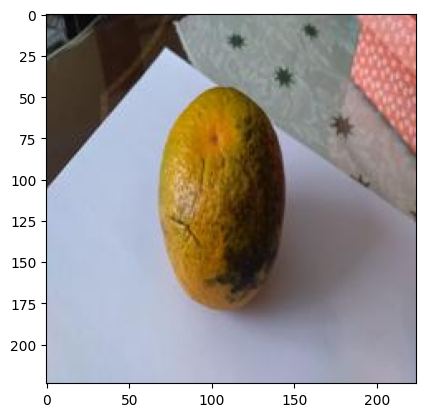

In [54]:
plt.imshow(images[0].permute(1,2,0))
plt.show()

In [55]:
labels[0]

tensor(12)

In [57]:
dataset.classes

['F_Banana',
 'F_Lemon',
 'F_Lulo',
 'F_Mango',
 'F_Orange',
 'F_Strawberry',
 'F_Tamarillo',
 'F_Tomato',
 'S_Banana',
 'S_Lemon',
 'S_Lulo',
 'S_Mango',
 'S_Orange',
 'S_Strawberry',
 'S_Tamarillo',
 'S_Tomato']

In [58]:
labels[1]

tensor(7)

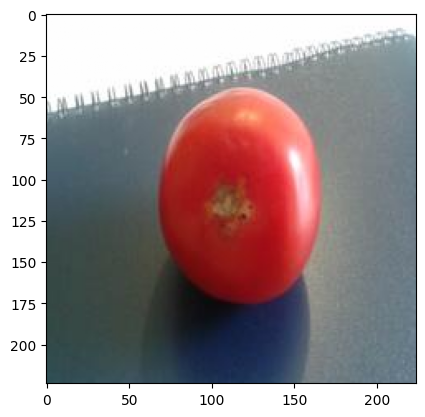

In [59]:
plt.imshow(images[1].permute(1,2,0))
plt.show()

In [61]:
print(train_dataset_full.classes[labels[0]])

S_Orange


In [63]:
print(train_dataset_full.classes[labels[1]])

F_Tomato


In [104]:
class FruitClassifierCNN(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.network=nn.Sequential(
            nn.Conv2d(in_channels=3,out_channels=32,kernel_size=3,padding=1), # (32,224,224)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2), # 32,112,112
                
            nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,padding=1), # (64,112,112)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2), # 64,56,56

            nn.Conv2d(in_channels=64,out_channels=128,kernel_size=3,padding=1), # (128,56,56)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2) # 128,28,28
             )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*28*28,128),
            nn.ReLU(),
            nn.Linear(128,num_classes)
        )

    def forward(self,x):
        x=self.network(x)
        x = self.classifier(x)
        return x

### Create Model

In [105]:
model= FruitClassifierCNN(num_classes=num_classes).to(device)

### Loss Function

In [110]:
criterion = nn.CrossEntropyLoss()

### Optimizer

In [111]:
optimizer = optim.Adam(model.parameters(),lr=0.001)

### Model Training

In [117]:
import time

def train_model(model, criterion, optimizer, epochs=5):

    start = time.time()

    epoch_log = []
    
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):

        model.train()

        running_loss = 0.0

        train_correct = 0
        train_total = 0

        for batch_num, (images, labels) in enumerate(train_loader):

            images = images.to(device)
            labels = labels.to(device)

            # Clear gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            # Backward pass
            loss.backward()

            # Update weights
            optimizer.step()

            # Add batch loss
            running_loss += loss.item() * images.size(0)

            _,predicted=torch.max(outputs,1)
            train_total+=labels.size(0)
            train_correct += (predicted == labels).sum().item()

            # Print every 10 batches
            if (batch_num + 1) % 10 == 0:

                print(
                    f"Epoch: {epoch+1}, "
                    f"Batch: {batch_num+1}, "
                    f"Loss: {loss.item():.4f}"
                )

        # =====================
        # Average Training Loss
        # =====================

        epoch_loss = running_loss / len(train_loader.dataset)
        train_accuracy = 100 * train_correct / train_total

        print(
            f"Epoch [{epoch+1}/{epochs}], "
            f"Training Loss: {epoch_loss:.4f}"
        )
        print(
            f"Training Accuracy: {train_accuracy:.2f}%"
        )

        # =====================
        # Validation
        # =====================

        model.eval()

        correct = 0
        total = 0

        all_labels = []
        all_predictions = []

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                # Forward pass
                outputs = model(images)

                # Get predicted class
                _, predicted = torch.max(outputs, 1)

                # Count total images
                total += labels.size(0)

                # Count correct predictions
                correct += (predicted == labels).sum().item()

                # Store actual and predicted labels
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())

        # Calculate validation accuracy
        validation_accuracy = 100 * correct / total

        print(
            f"*** Validation Accuracy: "
            f"{validation_accuracy:.2f}% ***"
        )
        # Save Epoch Log
        epoch_log.append({
            "Epoch": epoch + 1,
            "Training Loss": epoch_loss,
            "Training Accuracy": train_accuracy,
            "Validation Accuracy": validation_accuracy
        })
        

    # =====================
    # Execution Time
    # =====================

    end = time.time()

    print(
        f"\nExecution time: "
        f"{end - start:.2f} seconds"
    )

    return epoch_log,all_labels, all_predictions

In [137]:
# Instantiate the training_model, loss function, and optimizer
model_3 = FruitClassifierCNN(num_classes=num_classes).to(device)
criterion_3 = nn.CrossEntropyLoss()
optimizer_3 = optim.Adam(model_3.parameters(),lr=0.001)

### Experiment-1 with 3 Epochs

In [138]:
epoch_log_3,all_labels_3, all_predictions_3 = train_model(model_3, criterion_3, optimizer_3, 3)

Epoch: 1, Batch: 10, Loss: 2.7529
Epoch: 1, Batch: 20, Loss: 2.5798
Epoch: 1, Batch: 30, Loss: 2.1343
Epoch: 1, Batch: 40, Loss: 1.6740
Epoch: 1, Batch: 50, Loss: 1.4606
Epoch: 1, Batch: 60, Loss: 1.4988
Epoch: 1, Batch: 70, Loss: 1.8637
Epoch: 1, Batch: 80, Loss: 1.3961
Epoch: 1, Batch: 90, Loss: 1.2525
Epoch: 1, Batch: 100, Loss: 0.9256
Epoch: 1, Batch: 110, Loss: 1.2611
Epoch: 1, Batch: 120, Loss: 0.8985
Epoch: 1, Batch: 130, Loss: 0.9830
Epoch: 1, Batch: 140, Loss: 0.9157
Epoch: 1, Batch: 150, Loss: 0.8868
Epoch: 1, Batch: 160, Loss: 0.9383
Epoch: 1, Batch: 170, Loss: 0.6667
Epoch [1/3], Training Loss: 1.4519
Training Accuracy: 52.96%
*** Validation Accuracy: 74.00% ***
Epoch: 2, Batch: 10, Loss: 0.5183
Epoch: 2, Batch: 20, Loss: 0.7530
Epoch: 2, Batch: 30, Loss: 0.8173
Epoch: 2, Batch: 40, Loss: 0.7144
Epoch: 2, Batch: 50, Loss: 0.5544
Epoch: 2, Batch: 60, Loss: 0.4889
Epoch: 2, Batch: 70, Loss: 0.8834
Epoch: 2, Batch: 80, Loss: 0.6759
Epoch: 2, Batch: 90, Loss: 0.5569
Epoch: 2, B

In [139]:
log_df_3 = pd.DataFrame(epoch_log_3)

log_df_3

,Epoch,Training Loss,Training Accuracy,Validation Accuracy
0,1,1.451874,52.955357,74.000000
1,2,0.527163,82.214286,86.250000
2,3,0.302140,89.866071,89.666667


### Experiment-2 with 5 Epochs

In [119]:
epoch_log,all_labels, all_predictions = train_model(model, criterion, optimizer, 5)

Epoch: 1, Batch: 10, Loss: 2.7680
Epoch: 1, Batch: 20, Loss: 2.6352
Epoch: 1, Batch: 30, Loss: 2.4701
Epoch: 1, Batch: 40, Loss: 1.9688
Epoch: 1, Batch: 50, Loss: 2.0658
Epoch: 1, Batch: 60, Loss: 1.6232
Epoch: 1, Batch: 70, Loss: 1.3560
Epoch: 1, Batch: 80, Loss: 1.1867
Epoch: 1, Batch: 90, Loss: 1.1503
Epoch: 1, Batch: 100, Loss: 0.9652
Epoch: 1, Batch: 110, Loss: 0.9018
Epoch: 1, Batch: 120, Loss: 0.9454
Epoch: 1, Batch: 130, Loss: 0.9204
Epoch: 1, Batch: 140, Loss: 0.9766
Epoch: 1, Batch: 150, Loss: 0.7713
Epoch: 1, Batch: 160, Loss: 0.9869
Epoch: 1, Batch: 170, Loss: 0.5381
Epoch [1/5], Training Loss: 1.4710
Training Accuracy: 53.03%
*** Validation Accuracy: 74.83% ***
Epoch: 2, Batch: 10, Loss: 0.4775
Epoch: 2, Batch: 20, Loss: 0.4541
Epoch: 2, Batch: 30, Loss: 0.5267
Epoch: 2, Batch: 40, Loss: 0.4358
Epoch: 2, Batch: 50, Loss: 0.4909
Epoch: 2, Batch: 60, Loss: 0.4296
Epoch: 2, Batch: 70, Loss: 0.6372
Epoch: 2, Batch: 80, Loss: 0.3739
Epoch: 2, Batch: 90, Loss: 0.3844
Epoch: 2, B

### Evaluation on test dataset

In [120]:
def evaluate_model(model, test_loader, device):

    model.eval()

    correct = 0
    total = 0

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            # Get model predictions
            outputs = model(images)

            # Get predicted class
            _, predicted = torch.max(outputs, 1)

            # Count total images
            total += labels.size(0)

            # Count correct predictions
            correct += (predicted == labels).sum().item()

            # Save actual and predicted labels
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    accuracy = 100 * correct / total

    print(f"Test Accuracy: {accuracy:.2f}%")

    return accuracy, all_labels, all_predictions

In [121]:
test_accuracy, test_labels, test_predictions = evaluate_model(
    model,
    test_loader,
    device
)

Test Accuracy: 90.50%


In [123]:
import pandas as pd
log_df = pd.DataFrame(epoch_log)

log_df

,Epoch,Training Loss,Training Accuracy,Validation Accuracy
0,1,1.471032,53.026786,74.833333
1,2,0.476517,84.312500,85.458333
2,3,0.259186,91.080357,89.666667
3,4,0.149678,95.008929,90.916667
4,5,0.118022,96.133929,90.166667


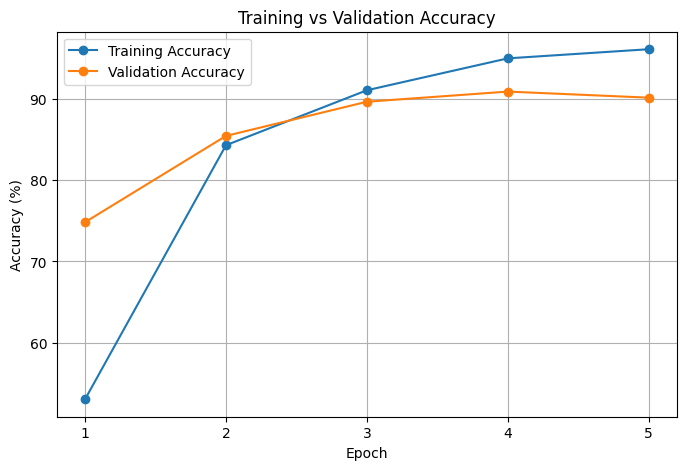

In [124]:
plt.figure(figsize=(8, 5))

plt.plot(
    log_df["Epoch"],
    log_df["Training Accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    log_df["Epoch"],
    log_df["Validation Accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title("Training vs Validation Accuracy")

plt.xticks(log_df["Epoch"])

plt.legend()

plt.grid(True)

plt.show()

### Experiment-3 with 10 Epochs

In [128]:
model_10 = FruitClassifierCNN(num_classes=16).to(device)

criterion = nn.CrossEntropyLoss()

optimizer_10 = torch.optim.Adam(
    model_10.parameters(),
    lr=0.001
)

In [129]:
epoch_log_10, labels_10, predictions_10 = train_model(
    model_10,
    criterion,
    optimizer_10,
    epochs=10
)

Epoch: 1, Batch: 10, Loss: 2.7874
Epoch: 1, Batch: 20, Loss: 2.6471
Epoch: 1, Batch: 30, Loss: 2.2364
Epoch: 1, Batch: 40, Loss: 2.2609
Epoch: 1, Batch: 50, Loss: 1.7214
Epoch: 1, Batch: 60, Loss: 1.5704
Epoch: 1, Batch: 70, Loss: 1.6119
Epoch: 1, Batch: 80, Loss: 1.6237
Epoch: 1, Batch: 90, Loss: 1.3509
Epoch: 1, Batch: 100, Loss: 1.2383
Epoch: 1, Batch: 110, Loss: 1.3671
Epoch: 1, Batch: 120, Loss: 1.3500
Epoch: 1, Batch: 130, Loss: 0.9062
Epoch: 1, Batch: 140, Loss: 1.1702
Epoch: 1, Batch: 150, Loss: 1.2036
Epoch: 1, Batch: 160, Loss: 1.1716
Epoch: 1, Batch: 170, Loss: 1.2056
Epoch [1/10], Training Loss: 1.6020
Training Accuracy: 48.25%
*** Validation Accuracy: 67.50% ***
Epoch: 2, Batch: 10, Loss: 0.5842
Epoch: 2, Batch: 20, Loss: 0.7291
Epoch: 2, Batch: 30, Loss: 0.9122
Epoch: 2, Batch: 40, Loss: 0.5739
Epoch: 2, Batch: 50, Loss: 0.7323
Epoch: 2, Batch: 60, Loss: 0.5639
Epoch: 2, Batch: 70, Loss: 0.3597
Epoch: 2, Batch: 80, Loss: 0.4941
Epoch: 2, Batch: 90, Loss: 0.4721
Epoch: 2, 

In [130]:
log_10 = pd.DataFrame(epoch_log_10)

log_10

,Epoch,Training Loss,Training Accuracy,Validation Accuracy
0,1,1.602020,48.250000,67.500000
1,2,0.548089,81.928571,88.083333
2,3,0.269259,90.794643,88.166667
3,4,0.136326,95.464286,92.333333
4,5,0.126364,96.062500,90.708333
5,6,0.060448,98.098214,93.208333
6,7,0.064841,98.080357,92.375000
7,8,0.051444,98.544643,95.125000
8,9,0.065071,97.973214,94.041667
9,10,0.009990,99.750000,96.958333


When we compare the log tables for epoch-3, epoch-5 and epoch-10, we can observe that the Best Epoch = 10
Best Validation Accuracy = 96.95%

Now the goal is to refine the model, address any overfitting, and achieve the best possible accuracy through fine-tuning and optimization techniques.

### Training and Validation: Plot training and validation accuracy to check for overfitting.

In [141]:
log_10.columns

Index(['Epoch', 'Training Loss', 'Training Accuracy', 'Validation Accuracy'], dtype='object')

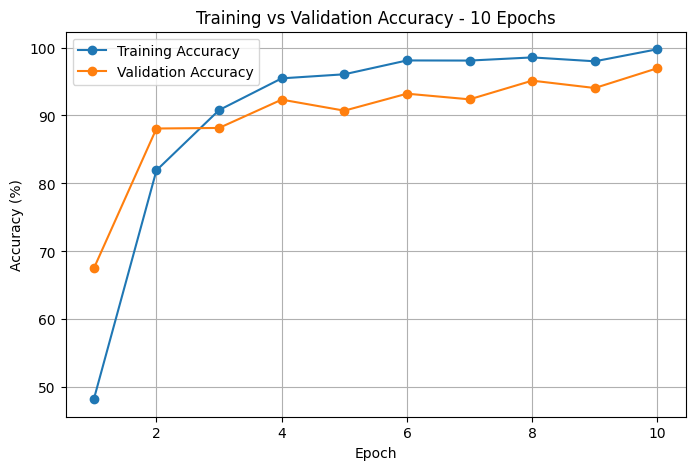

In [142]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    log_10["Epoch"],
    log_10["Training Accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    log_10["Epoch"],
    log_10["Validation Accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy - 10 Epochs")
plt.legend()
plt.grid(True)
plt.show()

### Regularization Techniques: Apply techniques like batch normalization, weight decay, dropout, and early stopping to improve model performance.

### 1. Batch Normalization

In [143]:
class FruitClassifierCNN_with_BatchNormalization(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.network=nn.Sequential(
            nn.Conv2d(in_channels=3,out_channels=32,kernel_size=3,padding=1), # (32,224,224)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2), # 32,112,112
                
            nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,padding=1), # (64,112,112)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2), # 64,56,56

            nn.Conv2d(in_channels=64,out_channels=128,kernel_size=3,padding=1), # (128,56,56)
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2) # 128,28,28
             )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*28*28,128),
            nn.ReLU(),
            nn.Linear(128,num_classes)
        )

    def forward(self,x):
        x=self.network(x)
        x = self.classifier(x)
        return x

In [144]:
model_bn = FruitClassifierCNN_with_BatchNormalization(
    num_classes=16
).to(device)

In [145]:
criterion_bn = nn.CrossEntropyLoss()

In [146]:
optimizer_bn = torch.optim.Adam(
    model_bn.parameters(),
    lr=0.001
)

#### Train for 10 epochs with batch normalization

In [147]:
epoch_log_bn, labels_bn, predictions_bn = train_model(
    model_bn,
    criterion_bn,
    optimizer_bn,
    epochs=10
)

Epoch: 1, Batch: 10, Loss: 8.6082
Epoch: 1, Batch: 20, Loss: 3.5930
Epoch: 1, Batch: 30, Loss: 2.4532
Epoch: 1, Batch: 40, Loss: 2.1153
Epoch: 1, Batch: 50, Loss: 1.9436
Epoch: 1, Batch: 60, Loss: 1.8631
Epoch: 1, Batch: 70, Loss: 2.0692
Epoch: 1, Batch: 80, Loss: 2.0081
Epoch: 1, Batch: 90, Loss: 1.2024
Epoch: 1, Batch: 100, Loss: 1.5641
Epoch: 1, Batch: 110, Loss: 1.4610
Epoch: 1, Batch: 120, Loss: 1.1731
Epoch: 1, Batch: 130, Loss: 1.7472
Epoch: 1, Batch: 140, Loss: 1.3485
Epoch: 1, Batch: 150, Loss: 1.0765
Epoch: 1, Batch: 160, Loss: 1.2797
Epoch: 1, Batch: 170, Loss: 1.1484
Epoch [1/10], Training Loss: 2.8125
Training Accuracy: 44.18%
*** Validation Accuracy: 59.12% ***
Epoch: 2, Batch: 10, Loss: 1.4167
Epoch: 2, Batch: 20, Loss: 1.3746
Epoch: 2, Batch: 30, Loss: 1.1835
Epoch: 2, Batch: 40, Loss: 0.9375
Epoch: 2, Batch: 50, Loss: 0.9576
Epoch: 2, Batch: 60, Loss: 1.0736
Epoch: 2, Batch: 70, Loss: 1.1722
Epoch: 2, Batch: 80, Loss: 0.6689
Epoch: 2, Batch: 90, Loss: 0.8435
Epoch: 2, 

In [148]:
log_bn = pd.DataFrame(epoch_log_bn)

log_bn

,Epoch,Training Loss,Training Accuracy,Validation Accuracy
0,1,2.812469,44.178571,59.125000
1,2,0.931179,70.044643,71.333333
2,3,0.549189,81.642857,80.625000
3,4,0.376867,87.098214,87.000000
4,5,0.296251,90.107143,90.208333
5,6,0.221503,92.437500,88.958333
6,7,0.160106,94.633929,79.541667
7,8,0.164544,94.500000,85.250000
8,9,0.114236,95.955357,84.125000
9,10,0.096812,96.857143,92.750000


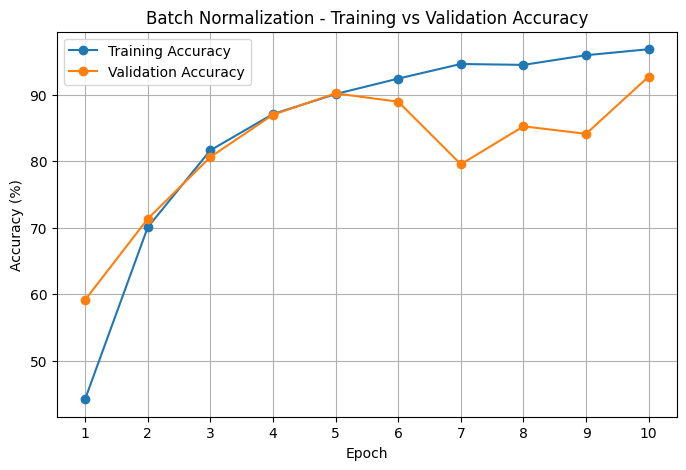

In [149]:
plt.figure(figsize=(8, 5))
plt.plot(
    log_bn["Epoch"],
    log_bn["Training Accuracy"],
    marker="o",
    label="Training Accuracy"
)
plt.plot(
    log_bn["Epoch"],
    log_bn["Validation Accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Batch Normalization - Training vs Validation Accuracy")

plt.xticks(log_bn["Epoch"])
plt.legend()
plt.grid(True)
plt.show()

In [150]:
log_bn

,Epoch,Training Loss,Training Accuracy,Validation Accuracy
0,1,2.812469,44.178571,59.125000
1,2,0.931179,70.044643,71.333333
2,3,0.549189,81.642857,80.625000
3,4,0.376867,87.098214,87.000000
4,5,0.296251,90.107143,90.208333
5,6,0.221503,92.437500,88.958333
6,7,0.160106,94.633929,79.541667
7,8,0.164544,94.500000,85.250000
8,9,0.114236,95.955357,84.125000
9,10,0.096812,96.857143,92.750000


#### Baseline CNN:Validation Accuracy = 96.96% With BatchNormalization result: Validation Accuracy = 92.75% so, in this particular experiment, Batch Normalization did not improve validation accuracy.

### 2. Dropout Layer

In [151]:
class FruitClassifierCNN_with_Dropout(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.network=nn.Sequential(
            nn.Conv2d(in_channels=3,out_channels=32,kernel_size=3,padding=1), # (32,224,224)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2), # 32,112,112
                
            nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,padding=1), # (64,112,112)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2), # 64,56,56

            nn.Conv2d(in_channels=64,out_channels=128,kernel_size=3,padding=1), # (128,56,56)
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2) # 128,28,28
             )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*28*28,128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128,num_classes)
        )

    def forward(self,x):
        x=self.network(x)
        x = self.classifier(x)
        return x

In [152]:
model_dropout = FruitClassifierCNN_with_Dropout(
    num_classes=16
).to(device)

criterion_dropout = nn.CrossEntropyLoss()

optimizer_dropout = torch.optim.Adam(
    model_dropout.parameters(),
    lr=0.001
)

In [153]:
epoch_log_dropout, labels_dropout, predictions_dropout = train_model(
    model_dropout,
    criterion_dropout,
    optimizer_dropout,
    epochs=10
)

Epoch: 1, Batch: 10, Loss: 3.0698
Epoch: 1, Batch: 20, Loss: 2.7405
Epoch: 1, Batch: 30, Loss: 2.7556
Epoch: 1, Batch: 40, Loss: 2.7088
Epoch: 1, Batch: 50, Loss: 2.8136
Epoch: 1, Batch: 60, Loss: 2.6477
Epoch: 1, Batch: 70, Loss: 2.7703
Epoch: 1, Batch: 80, Loss: 2.6866
Epoch: 1, Batch: 90, Loss: 2.7063
Epoch: 1, Batch: 100, Loss: 2.7753
Epoch: 1, Batch: 110, Loss: 2.7041
Epoch: 1, Batch: 120, Loss: 2.6719
Epoch: 1, Batch: 130, Loss: 2.5881
Epoch: 1, Batch: 140, Loss: 2.6593
Epoch: 1, Batch: 150, Loss: 2.5289
Epoch: 1, Batch: 160, Loss: 2.7002
Epoch: 1, Batch: 170, Loss: 2.5489
Epoch [1/10], Training Loss: 3.3865
Training Accuracy: 10.47%
*** Validation Accuracy: 18.71% ***
Epoch: 2, Batch: 10, Loss: 2.4109
Epoch: 2, Batch: 20, Loss: 2.5017
Epoch: 2, Batch: 30, Loss: 2.5608
Epoch: 2, Batch: 40, Loss: 2.5052
Epoch: 2, Batch: 50, Loss: 2.5743
Epoch: 2, Batch: 60, Loss: 2.4948
Epoch: 2, Batch: 70, Loss: 2.4695
Epoch: 2, Batch: 80, Loss: 2.7203
Epoch: 2, Batch: 90, Loss: 2.5467
Epoch: 2, 

In [154]:
log_dropout = pd.DataFrame(epoch_log_dropout)

log_dropout

,Epoch,Training Loss,Training Accuracy,Validation Accuracy
0,1,3.386460,10.473214,18.708333
1,2,2.516232,14.008929,19.916667
2,3,2.428079,16.660714,26.958333
3,4,2.355772,18.205357,24.208333
4,5,2.302711,18.598214,33.583333
5,6,2.259664,19.946429,31.416667
6,7,2.252005,19.250000,34.416667
7,8,2.219473,19.839286,33.583333
8,9,2.212685,20.116071,36.208333
9,10,2.205486,20.392857,40.250000


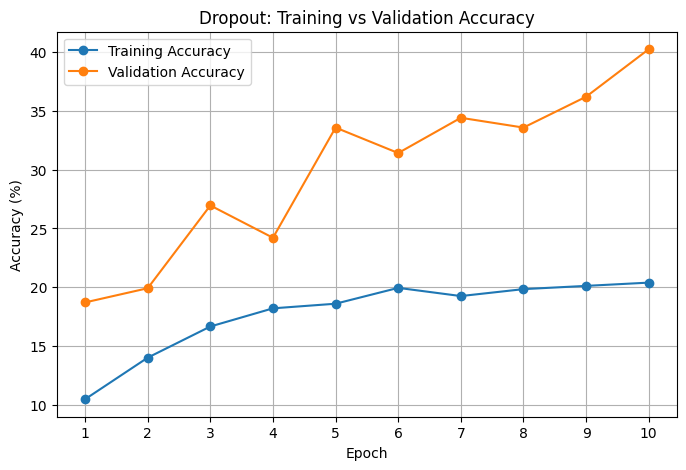

In [155]:
plt.figure(figsize=(8, 5))

plt.plot(
    log_dropout["Epoch"],
    log_dropout["Training Accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    log_dropout["Epoch"],
    log_dropout["Validation Accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Dropout: Training vs Validation Accuracy")

plt.xticks(log_dropout["Epoch"])
plt.legend()
plt.grid(True)

plt.show()

Dropout was applied as a regularization technique to reduce overfitting in the CNN model. A dropout rate of 0.5 was used and the model was trained for 10 epochs.

The model's training accuracy increased from 10.47% to 20.39%, while validation accuracy increased from 18.71% to 40.25%. Although the model showed gradual learning, its performance was significantly lower than the baseline CNN, which achieved a validation accuracy of 96.96%.

In [159]:
class FruitClassifierCNN_with_Dropout_2(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(128 * 28 * 28, 128),

            nn.ReLU(),

            nn.Dropout(0.2),   # changed from 0.5 to 0.2

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.network(x)
        x = self.classifier(x)
        return x

In [160]:
model_dropout02 = FruitClassifierCNN_with_Dropout_2(
    num_classes=16
).to(device)

In [161]:
criterion_dropout02 = nn.CrossEntropyLoss()

optimizer_dropout02 = torch.optim.Adam(
    model_dropout02.parameters(),
    lr=0.001
)

In [162]:
epoch_log_dropout02, labels_dropout02, predictions_dropout02 = train_model(
    model_dropout02,
    criterion_dropout02,
    optimizer_dropout02,
    epochs=10
)

Epoch: 1, Batch: 10, Loss: 2.7992
Epoch: 1, Batch: 20, Loss: 2.6841
Epoch: 1, Batch: 30, Loss: 2.4066
Epoch: 1, Batch: 40, Loss: 2.3083
Epoch: 1, Batch: 50, Loss: 2.2802
Epoch: 1, Batch: 60, Loss: 1.9701
Epoch: 1, Batch: 70, Loss: 2.2318
Epoch: 1, Batch: 80, Loss: 2.0192
Epoch: 1, Batch: 90, Loss: 1.3685
Epoch: 1, Batch: 100, Loss: 1.6795
Epoch: 1, Batch: 110, Loss: 1.5569
Epoch: 1, Batch: 120, Loss: 1.5602
Epoch: 1, Batch: 130, Loss: 1.2816
Epoch: 1, Batch: 140, Loss: 0.9440
Epoch: 1, Batch: 150, Loss: 1.1667
Epoch: 1, Batch: 160, Loss: 1.1035
Epoch: 1, Batch: 170, Loss: 1.0044
Epoch [1/10], Training Loss: 1.7826
Training Accuracy: 42.11%
*** Validation Accuracy: 72.62% ***
Epoch: 2, Batch: 10, Loss: 0.7081
Epoch: 2, Batch: 20, Loss: 1.0771
Epoch: 2, Batch: 30, Loss: 1.0205
Epoch: 2, Batch: 40, Loss: 0.9556
Epoch: 2, Batch: 50, Loss: 0.6705
Epoch: 2, Batch: 60, Loss: 0.6785
Epoch: 2, Batch: 70, Loss: 0.6624
Epoch: 2, Batch: 80, Loss: 0.8819
Epoch: 2, Batch: 90, Loss: 0.4507
Epoch: 2, 

In [163]:
log_dropout02 = pd.DataFrame(epoch_log_dropout02)

log_dropout02

,Epoch,Training Loss,Training Accuracy,Validation Accuracy
0,1,1.782566,42.107143,72.625000
1,2,0.701715,76.455357,83.666667
2,3,0.423359,85.553571,89.416667
3,4,0.313470,89.223214,92.041667
4,5,0.217066,92.294643,91.291667
5,6,0.162583,94.428571,92.416667
6,7,0.130431,95.392857,93.166667
7,8,0.135450,95.571429,93.291667
8,9,0.083826,97.071429,92.583333
9,10,0.095568,96.705357,95.291667


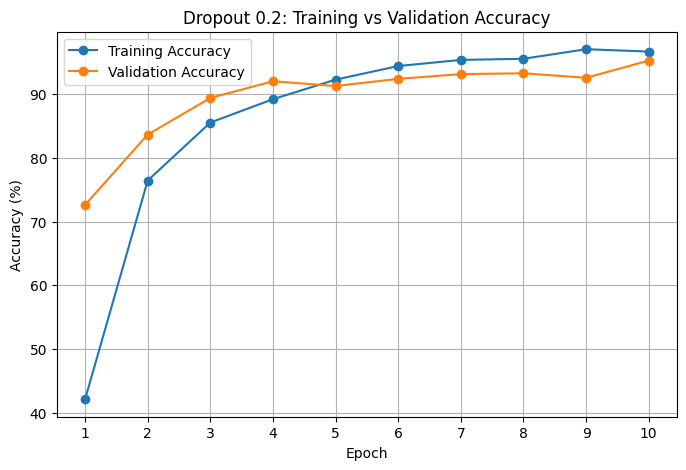

In [164]:
plt.figure(figsize=(8, 5))

plt.plot(
    log_dropout02["Epoch"],
    log_dropout02["Training Accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    log_dropout02["Epoch"],
    log_dropout02["Validation Accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Dropout 0.2: Training vs Validation Accuracy")

plt.xticks(log_dropout02["Epoch"])
plt.legend()
plt.grid(True)

plt.show()

Dropout with a rate of 0.2 was applied to the fully connected layer and the model was trained for 10 epochs. The model achieved a best validation accuracy of 95.29% at Epoch 10. Compared with Dropout 0.5, which achieved only 40.25% validation accuracy, Dropout 0.2 provided substantially better learning and generalization. However, the baseline CNN achieved a slightly higher validation accuracy of 96.96%. Therefore, Dropout 0.2 was more effective than Dropout 0.5 for this FreshHarvest dataset but did not outperform the baseline model.

### 3. Weight Decay

In [165]:
model_wd = FruitClassifierCNN(
    num_classes=16
).to(device)

In [166]:
criterion_wd = nn.CrossEntropyLoss()

In [167]:
optimizer_wd = torch.optim.Adam(
    model_wd.parameters(),
    lr=0.001,
    weight_decay=0.0001
)

In [168]:
epoch_log_wd, labels_wd, predictions_wd = train_model(
    model_wd,
    criterion_wd,
    optimizer_wd,
    epochs=10
)

Epoch: 1, Batch: 10, Loss: 2.7496
Epoch: 1, Batch: 20, Loss: 2.6348
Epoch: 1, Batch: 30, Loss: 2.5411
Epoch: 1, Batch: 40, Loss: 2.0554
Epoch: 1, Batch: 50, Loss: 1.7623
Epoch: 1, Batch: 60, Loss: 1.6325
Epoch: 1, Batch: 70, Loss: 1.8181
Epoch: 1, Batch: 80, Loss: 1.3720
Epoch: 1, Batch: 90, Loss: 1.3877
Epoch: 1, Batch: 100, Loss: 0.7990
Epoch: 1, Batch: 110, Loss: 1.0672
Epoch: 1, Batch: 120, Loss: 0.9725
Epoch: 1, Batch: 130, Loss: 0.9412
Epoch: 1, Batch: 140, Loss: 0.9984
Epoch: 1, Batch: 150, Loss: 0.8594
Epoch: 1, Batch: 160, Loss: 0.7741
Epoch: 1, Batch: 170, Loss: 0.8923
Epoch [1/10], Training Loss: 1.5240
Training Accuracy: 51.38%
*** Validation Accuracy: 72.25% ***
Epoch: 2, Batch: 10, Loss: 0.6005
Epoch: 2, Batch: 20, Loss: 0.4801
Epoch: 2, Batch: 30, Loss: 0.5939
Epoch: 2, Batch: 40, Loss: 0.4577
Epoch: 2, Batch: 50, Loss: 0.3923
Epoch: 2, Batch: 60, Loss: 0.4686
Epoch: 2, Batch: 70, Loss: 0.3424
Epoch: 2, Batch: 80, Loss: 0.4307
Epoch: 2, Batch: 90, Loss: 0.7798
Epoch: 2, 

In [169]:
log_wd = pd.DataFrame(epoch_log_wd)

log_wd

,Epoch,Training Loss,Training Accuracy,Validation Accuracy
0,1,1.524035,51.383929,72.250000
1,2,0.484478,84.125000,88.541667
2,3,0.269349,90.964286,91.916667
3,4,0.180422,93.767857,90.250000
4,5,0.139181,95.500000,94.041667
5,6,0.094039,96.866071,92.666667
6,7,0.100078,96.669643,92.250000
7,8,0.085756,97.294643,92.208333
8,9,0.065451,97.857143,94.916667
9,10,0.077365,97.598214,92.875000


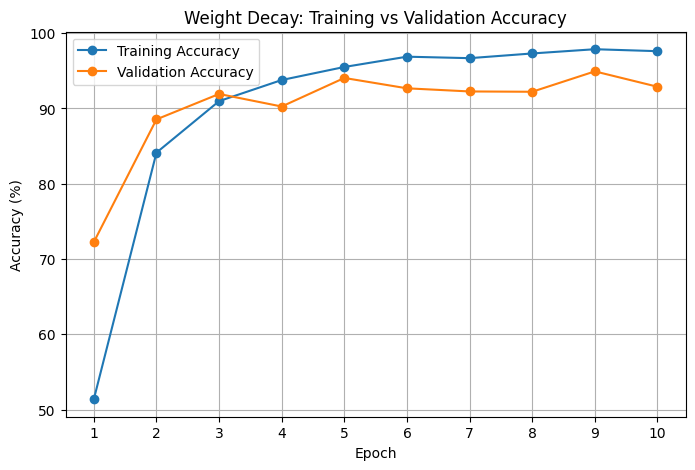

In [170]:
plt.figure(figsize=(8, 5))

plt.plot(
    log_wd["Epoch"],
    log_wd["Training Accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    log_wd["Epoch"],
    log_wd["Validation Accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Weight Decay: Training vs Validation Accuracy")

plt.xticks(log_wd["Epoch"])
plt.legend()
plt.grid(True)

plt.show()

Weight decay of 0.0001 was added to the Adam optimizer to reduce overfitting. The model was trained for 10 epochs and achieved its highest validation accuracy of 94.92% at Epoch 9. Although the model showed good generalization, it did not outperform the baseline CNN, which achieved 96.96% validation accuracy.

### Conclusion

 The baseline CNN achieved a training accuracy of 99.75% and a best validation accuracy of 96.95% at Epoch 10.. The regularization experiments with Batch Normalization, Dropout, and Weight Decay did not outperform the baseline on this dataset. Dropout with a rate of 0.2 performed relatively well at 95.29%, whereas Dropout 0.5 significantly reduced performance. Therefore, the baseline CNN was retained as the better-performing model based on validation accuracy.

#### Save Model

In [ ]:
baseline_model=model_10